## ANN Final Project: Detection of Social Engineering Attacks in Spam Messaging

Objectives (most to least importance):

1. Implement non-neural baselines
2. Feed-forward NN
    - FFN w/ one-hot encoding
    - FFN w/ pretrained word embeddings
    - FFN w/ pretrained word embeddings and attention
3. Bidirectional LSTM
4. Explainability analysis
5. Adversarial attacks
6. Calibration


###Part 0: Clean/Prep Data

In [ ]:
import pandas as pd
from bs4 import BeautifulSoup
import re

In [2]:
# ── 1. Load datasets ──────────────────────────────────────────────────────────

nazario = pd.read_csv('./sample_data/Nazario_5_datset.csv')
email_text = pd.read_csv('./sample_data/email_text.csv')

# ── 2. Extract relevant columns and rename to a unified schema ────────────────

# Nazario_5 uses 'body' and 'label'
nazario_clean = nazario[['body', 'label']].copy()
nazario_clean.columns = ['text', 'label']

# email_text uses 'text' and 'label'
email_clean = email_text[['text', 'label']].copy()

# ── 3. Combine datasets ───────────────────────────────────────────────────────

df = pd.concat([nazario_clean, email_clean], ignore_index=True)

# ── 4. Drop missing values ────────────────────────────────────────────────────

print(f"Rows before dropping nulls: {len(df)}")
df.dropna(subset=['text', 'label'], inplace=True)
print(f"Rows after dropping nulls:  {len(df)}")

# ── 5. Minimal text cleaning ──────────────────────────────────────────────────
# - Strip HTML tags (common in email bodies)
# - Collapse extra whitespace
# - Lowercase
# Punctuation is intentionally preserved as it carries spam signal

def minimal_clean(text):
    # Remove HTML tags
    text = BeautifulSoup(text, 'html.parser').get_text()
    # Collapse newlines/tabs/extra spaces into a single space
    text = re.sub(r'\s+', ' ', text).strip()
    # Lowercase
    text = text.lower()
    return text

df['text'] = df['text'].apply(minimal_clean)

# ── 6. Sanity check ───────────────────────────────────────────────────────────

print(f"\nFinal dataset shape: {df.shape}")
print(f"Class distribution:\n{df['label'].value_counts()}")
print(f"\nSample rows:")
df.head()

Rows before dropping nulls: 56733
Rows after dropping nulls:  56733

Final dataset shape: (56733, 2)
Class distribution:
label
1    31488
0    25245
Name: count, dtype: int64

Sample rows:


,text,label
0,user id: enrondlr pw: bnaweb22 -----original m...,0
1,"hi chris, tonight we are rolling out a new rep...",0
2,rika r these new? -----original message----- f...,0
3,"john/gerald, we are currently trading under gt...",0
4,gerald and stacy - attached is a worksheet for...,0


### Part 1: Implement Non-Neural Baseline, Generate Adversarial Examples

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Train: 40847 | Val: 4539 | Test: 11347
=== Clean Test Set ===
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      5049
        Spam       0.98      0.99      0.99      6298

    accuracy                           0.99     11347
   macro avg       0.99      0.99      0.99     11347
weighted avg       0.99      0.99      0.99     11347



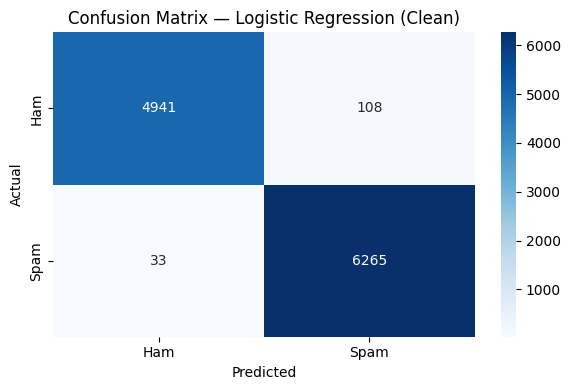

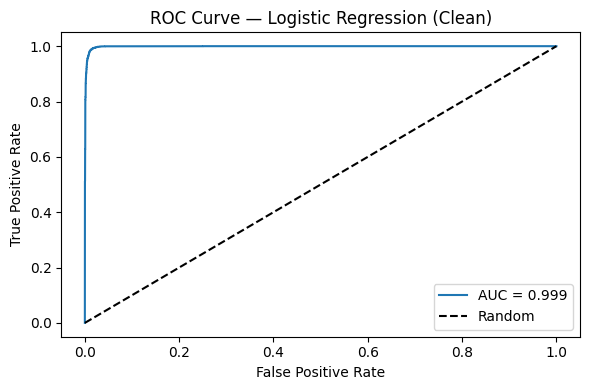

=== Adversarial Test Set ===
              precision    recall  f1-score   support

         Ham       1.00      0.97      0.98      5049
        Spam       0.97      1.00      0.98      6298

    accuracy                           0.98     11347
   macro avg       0.98      0.98      0.98     11347
weighted avg       0.98      0.98      0.98     11347



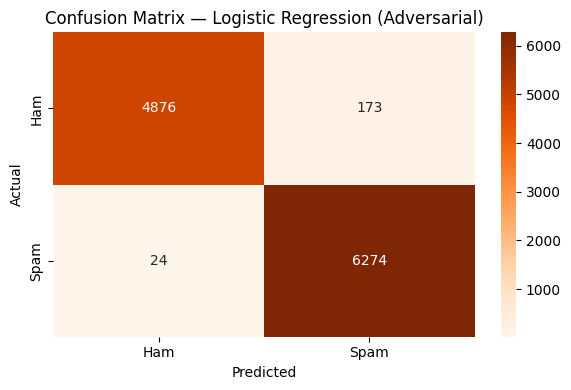

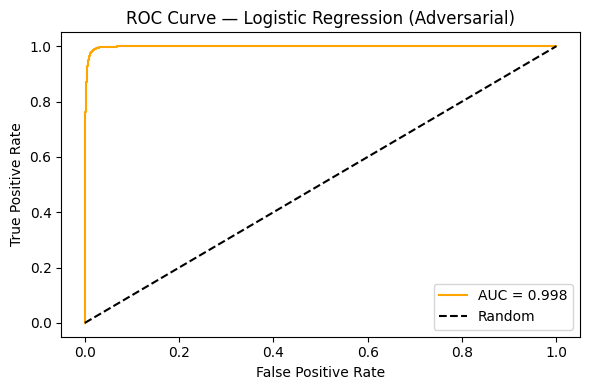

In [3]:
import re
import random
import nltk
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

# ── 1. Train/val/test split ───────────────────────────────────────────────────

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# ── 2. Generate adversarial examples from test set only ───────────────────────

def introduce_typos(text, rate=0.05):
    """Randomly swap adjacent characters in words to simulate typos."""
    words = text.split()
    for i, word in enumerate(words):
        if len(word) > 3 and random.random() < rate:
            idx = random.randint(0, len(word) - 2)
            word = word[:idx] + word[idx+1] + word[idx] + word[idx+2:]
            words[i] = word
    return ' '.join(words)

def get_synonym(word):
    """Return a synonym for a word if one exists, otherwise return the word."""
    synsets = wordnet.synsets(word)
    for synset in synsets:
        for lemma in synset.lemmas():
            if lemma.name().lower() != word.lower():
                return lemma.name().replace('_', ' ')
    return word

def synonym_replacement(text, rate=0.1):
    """Replace a fraction of words with synonyms."""
    words = text.split()
    for i, word in enumerate(words):
        if random.random() < rate:
            words[i] = get_synonym(word)
    return ' '.join(words)

def character_substitution(text):
    """Replace common characters with visual lookalikes."""
    substitutions = {'a': '@', 'e': '3', 'i': '1', 'o': '0', 's': '$'}
    return ''.join(substitutions.get(c, c) if random.random() < 0.3 else c
                   for c in text)

# suspicious cue words for signal-removing attack
SUSPICIOUS_TERMS = {
    "urgent", "immediately", "verify", "verification", "confirm", "login",
    "password", "account", "restricted", "suspended", "reset", "click",
    "bank", "security", "update", "expired", "unlock", "ssn"
}

def character_level_attack(text):
    """Character-level noise: typos + visual character substitutions."""
    text = introduce_typos(text, rate=0.2)
    text = character_substitution(text)
    return text


def semantic_preserving_attack(text):
    """Semantic-preserving changes: synonym replacements."""
    text = synonym_replacement(text, rate=0.4)
    return text


def signal_removing_attack(text, removal_prob=0.9):
    """Remove suspicious keywords to test keyword reliance."""
    words = text.split()
    filtered_words = []

    for word in words:
        clean_word = re.sub(r'[^\w]', '', word).lower()
        if clean_word in SUSPICIOUS_TERMS and random.random() < removal_prob:
            continue
        filtered_words.append(word)

    return ' '.join(filtered_words)


def formatting_structural_attack(text):
    """Change punctuation, spacing, and URL formatting."""
    text = re.sub(r'https?://', 'hxxp://', text, flags=re.IGNORECASE)
    text = re.sub(r'www\.', 'www[.]', text, flags=re.IGNORECASE)

    text = re.sub(r'!', ' !!!' if random.random() < 0.5 else '', text)
    text = re.sub(r'\?', ' ?' if random.random() < 0.5 else '', text)
    text = re.sub(r':', ' - ' if random.random() < 0.5 else ':', text)
    text = re.sub(r';', ' , ', text)

    text = re.sub(r'\s+', lambda m: '  ' if random.random() < 0.2 else ' ', text)

    if random.random() < 0.4:
        text = text.replace('. ', '.\n')

    text = re.sub(r'[ ]{2,}', '  ', text).strip()
    return text

ATTACK_FUNCTIONS = [
    character_level_attack,
    semantic_preserving_attack,
    signal_removing_attack,
    formatting_structural_attack
]


def combined_attack(text):
    attack_fn = random.choice(ATTACK_FUNCTIONS)
    return attack_fn(text)

random.seed(42)
X_test_adv = X_test.apply(combined_attack)



# ── 3. Fit TF-IDF on training data only ──────────────────────────────────────

vectorizer = TfidfVectorizer(
    max_features=20000,
    sublinear_tf=True,
    min_df=2,
)

X_train_tfidf   = vectorizer.fit_transform(X_train)
X_val_tfidf     = vectorizer.transform(X_val)
X_test_tfidf    = vectorizer.transform(X_test)
X_test_adv_tfidf = vectorizer.transform(X_test_adv)

# ── 4. Train logistic regression ──────────────────────────────────────────────

clf = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train_tfidf, y_train)

# ── 5. Evaluate on clean test set ─────────────────────────────────────────────

y_pred      = clf.predict(X_test_tfidf)
y_pred_prob = clf.predict_proba(X_test_tfidf)[:, 1]

print("=== Clean Test Set ===")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression (Clean)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Clean)')
plt.legend()
plt.tight_layout()
plt.show()

# ── 6. Evaluate on adversarial test set ───────────────────────────────────────

y_pred_adv      = clf.predict(X_test_adv_tfidf)
y_pred_adv_prob = clf.predict_proba(X_test_adv_tfidf)[:, 1]

print("=== Adversarial Test Set ===")
print(classification_report(y_test, y_pred_adv, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_adv), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Oranges')
plt.title('Confusion Matrix — Logistic Regression (Adversarial)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr_adv, tpr_adv, _ = roc_curve(y_test, y_pred_adv_prob)
roc_auc_adv = auc(fpr_adv, tpr_adv)
plt.figure(figsize=(6, 4))
plt.plot(fpr_adv, tpr_adv, color='orange', label=f'AUC = {roc_auc_adv:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression (Adversarial)')
plt.legend()
plt.tight_layout()
plt.show()

Based on the above results, we can see a basic Logistic Regression model trained using TF-IDF performs extremely well on the original data, achieving a 99% accuracy and almost-perfect precision and recall for both classes on the test data. This might be because the spam messages have such distinct vocabulary that it is easy for TF-IDF to distinguish their importance.

The model performs slightly worse on the adversarial inputs, achieving a 98% accuracy and a low of 97% recall on the 'ham' messages.

It is worth noting that the while the LSTM we develop might perform about the same, it should outperform the LogReg when given adversarial inputs since TF-IDF relies on exact token matching (and thus would be fooled by misspellings/synonyms/etc).

### Part 2: Feedforward NNs

#### FFNN w/ One-hot Encoding


=== FFNN (One-Hot Encoding) Model Summary ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,961 (2.48 MB)

 Trainable params: 648,705 (2.47 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9738 - loss: 0.0749 - val_accuracy: 0.9863 - val_loss: 0.0366
Epoch 2/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9922 - loss: 0.0269 - val_accuracy: 0.9901 - val_loss: 0.0287
Epoch 3/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9947 - loss: 0.0168 - val_accuracy: 0.9914 - val_loss: 0.0303
Epoch 4/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9966 - loss: 0.0116 - val_accuracy: 0.9905 - val_loss: 0.0315
Epoch 5/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9968 - loss: 0.0103 - val_accuracy: 0.9905 - val_loss: 0.0322

Best epoch: 2
Best val_loss: 0.0287
355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

=== FFNN (One-Hot) — Clean Test Set ===
              precision    recall  f1-score   support

         Ham       1.00      0.98      0.99      5049
        Spam       0.98      1.00      0.99      6298

    accuracy                           0.99     11347
   macro avg    

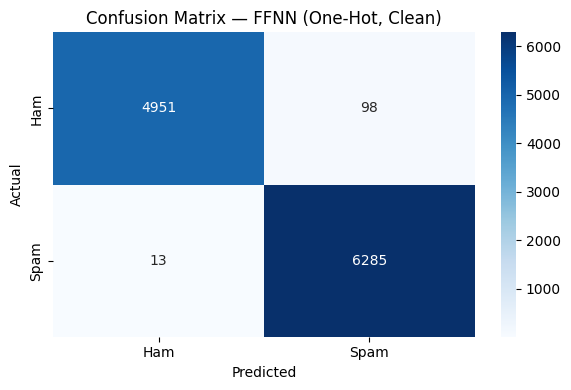

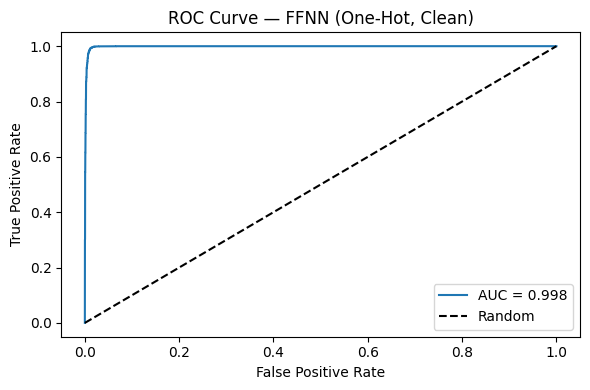

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

=== FFNN (One-Hot) — Adversarial Test Set ===
              precision    recall  f1-score   support

         Ham       1.00      0.95      0.98      5049
        Spam       0.96      1.00      0.98      6298

    accuracy                           0.98     11347
   macro avg       0.98      0.98      0.98     11347
weighted avg       0.98      0.98      0.98     11347



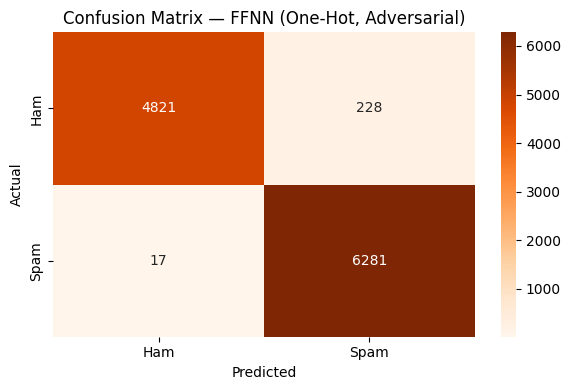

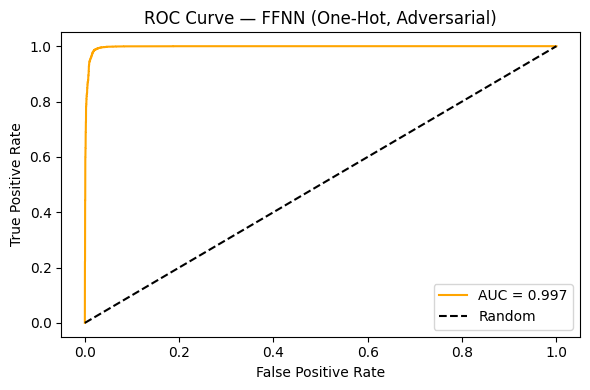

In [4]:
# ── FFNN (One-Hot Encoding) ────────────────────────────────────────────────

from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── 1. One-hot (binary) vectorization ────────────────────────────────────────

onehot_vectorizer = CountVectorizer(
    max_features=5000,   # had to lower from 20k to 5k due to memory constraints
    binary=True,
    min_df=2
)

X_train_oh    = onehot_vectorizer.fit_transform(X_train).toarray()
X_val_oh      = onehot_vectorizer.transform(X_val).toarray()
X_test_oh     = onehot_vectorizer.transform(X_test).toarray()
X_test_adv_oh = onehot_vectorizer.transform(X_test_adv).toarray()

# ── 2. Build FFNN model ───────────────────────────────────────────────────────

input_dim = X_train_oh.shape[1]

ffnn_onehot = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

ffnn_onehot.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-3),
    metrics=['accuracy']
)

print("\n=== FFNN (One-Hot Encoding) Model Summary ===")
ffnn_onehot.summary()

# ── 3. Train ──────────────────────────────────────────────────────────────────

history = ffnn_onehot.fit(
    X_train_oh, y_train,
    validation_data=(X_val_oh, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"\nBest epoch: {best_epoch}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

# ── 4. Evaluate on clean test set ─────────────────────────────────────────────

y_pred_prob = ffnn_onehot.predict(X_test_oh).ravel()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("\n=== FFNN (One-Hot) — Clean Test Set ===")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Blues')
plt.title('Confusion Matrix — FFNN (One-Hot, Clean)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — FFNN (One-Hot, Clean)')
plt.legend()
plt.tight_layout()
plt.show()

# ── 5. Evaluate on adversarial test set ───────────────────────────────────────

y_pred_adv_prob = ffnn_onehot.predict(X_test_adv_oh).ravel()
y_pred_adv      = (y_pred_adv_prob >= 0.5).astype(int)

print("\n=== FFNN (One-Hot) — Adversarial Test Set ===")
print(classification_report(y_test, y_pred_adv, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_adv), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Oranges')
plt.title('Confusion Matrix — FFNN (One-Hot, Adversarial)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr_adv, tpr_adv, _ = roc_curve(y_test, y_pred_adv_prob)
roc_auc_adv = auc(fpr_adv, tpr_adv)
plt.figure(figsize=(6, 4))
plt.plot(fpr_adv, tpr_adv, color='orange', label=f'AUC = {roc_auc_adv:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — FFNN (One-Hot, Adversarial)')
plt.legend()
plt.tight_layout()
plt.show()

We can see the FFNN w/ one-hot encoding is marginally better than the LogReg model for the clean test set and is marginally worse than the LogReg for the adversarial test set. The former makes sense as the FFNN has 2 dense layers, meaning it can learn that multiple spam words together are more suspicious than either word alone, something the LogReg cannot do. The latter also makes sense; since the FFNN learned more complex patterns from the data, it's more likely to break under adversarial inputs. In this instance, LogReg is more flexible to perturbations from the adversarial examples because it relies solely on the word weights, rather than how the words interact with each other.

#### FFNN w/ Pre-trained Word Embeddings

In [ ]:
# get word embeddings
import urllib.request
import zipfile
import os

if not os.path.exists('./glove.6B.100d.txt'):
    print("Downloading GloVe...")
    urllib.request.urlretrieve(
        "https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip",
        "./glove.6B.zip"
    )
    with zipfile.ZipFile('./glove.6B.zip', 'r') as z:
        z.extract('glove.6B.100d.txt', '.')
    print("Done.")
else:
    print("GloVe already downloaded.")

GloVe already downloaded.


In [ ]:
# build embedding matrix
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM    = 100       # matches glove.6B.100d
MAX_VOCAB    = 20000     # same as your TF-IDF max_features
MAX_LEN      = 300       # max tokens per message — tune based on your data

# ── Fit tokenizer on training text only ──────────────────────────────────────
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

word_index = tokenizer.word_index
print(f"Vocabulary size: {len(word_index)}")

# ── Pad sequences ─────────────────────────────────────────────────────────────
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN, padding='post', truncating='post')

# ── Load GloVe into a lookup dict ─────────────────────────────────────────────
glove_index = {}
with open('./glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_index[word] = vector

print(f"GloVe vectors loaded: {len(glove_index)}")

# ── Build embedding matrix ────────────────────────────────────────────────────
# Rows = vocab indices, Cols = 100-dim GloVe vector
# Words not found in GloVe stay as zero vectors (unknown words)
vocab_size       = min(MAX_VOCAB, len(word_index)) + 1   # +1 for padding index 0
embedding_matrix = np.zeros((vocab_size, EMBED_DIM))

found, not_found = 0, 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    vector = glove_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        found += 1
    else:
        not_found += 1

print(f"Words covered by GloVe: {found} | OOV (zero vector): {not_found}")

Vocabulary size: 253581
GloVe vectors loaded: 400000
Words covered by GloVe: 16072 | OOV (zero vector): 3928


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 300, 100)       │     2,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,021,861 (7.71 MB)

 Trainable params: 2,021,605 (7.71 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 28s 38ms/step - accuracy: 0.9448 - loss: 0.1476 - val_accuracy: 0.9828 - val_loss: 0.0519
Epoch 2/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9798 - loss: 0.0650 - val_accuracy: 0.9879 - val_loss: 0.0418
Epoch 3/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9859 - loss: 0.0470 - val_accuracy: 0.9835 - val_loss: 0.0534
Epoch 4/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9867 - loss: 0.0428 - val_accuracy: 0.9769 - val_loss: 0.0636
Epoch 5/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9892 - loss: 0.0331 - val_accuracy: 0.9874 - val_loss: 0.0351
Epoch 6/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.9910 - loss: 0.0291 - val_accuracy: 0.9848 - val_loss: 0.0467
Epoch 7/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 37s 31ms/step - accuracy: 0.9933 - loss: 0.0215 - val_accuracy: 0.9863 - val_loss: 0.0431
Epoch 8/20
639/639 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.9920 - loss: 0.0246 - 

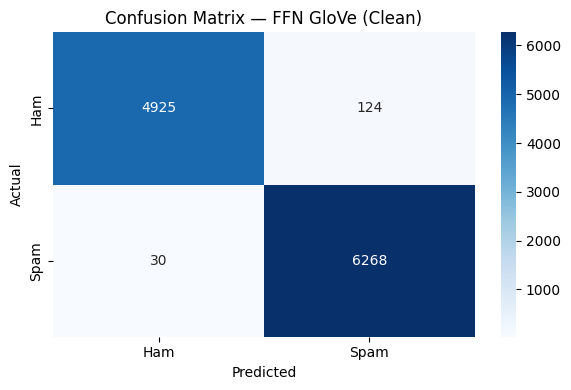

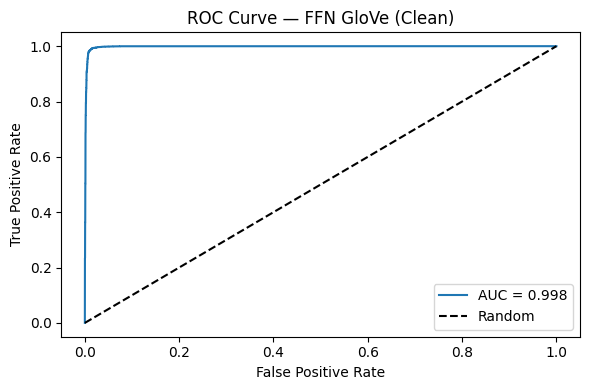

355/355 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
=== Adversarial Test Set ===
              precision    recall  f1-score   support

         Ham       1.00      0.88      0.93      5049
        Spam       0.91      1.00      0.95      6298

    accuracy                           0.94     11347
   macro avg       0.95      0.94      0.94     11347
weighted avg       0.95      0.94      0.94     11347



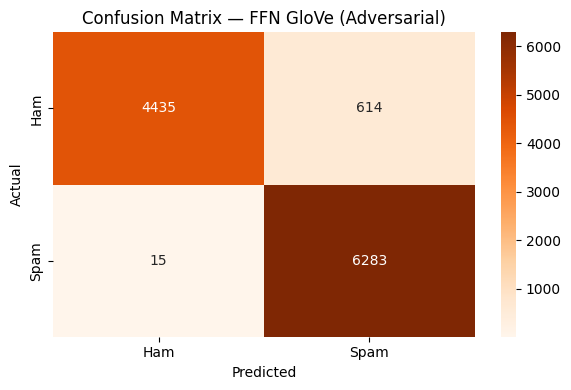

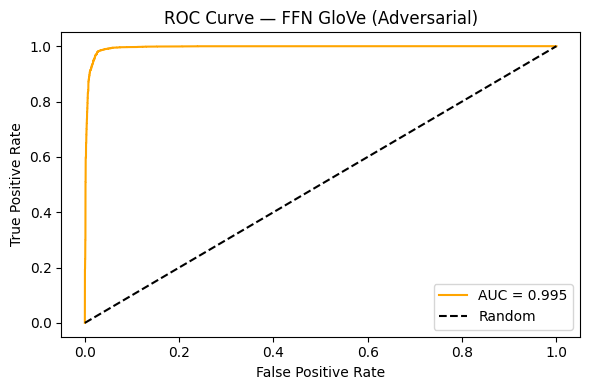

In [ ]:
# build & train FFNN using embeddings
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Flatten, GlobalAveragePooling1D,
    Dense, Dropout, BatchNormalization
)

def build_ffn_glove(vocab_size, embed_dim, max_len, embedding_matrix, trainable=False):
    """
    FFN using pretrained GloVe embeddings.
    trainable=False  → frozen embeddings (pure transfer learning)
    trainable=True   → fine-tune embeddings during training
    """
    inp = Input(shape=(max_len,))

    # Load GloVe weights; trainable controls whether they update during backprop
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=trainable          # False = frozen GloVe
    )(inp)

    # Pool across token dimension → single vector per message
    # GlobalAveragePooling averages all token embeddings (equivalent to mean bag-of-words in embedding space)
    x = GlobalAveragePooling1D()(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(1, activation='sigmoid')(x)  # binary output: spam probability

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


model_glove = build_ffn_glove(vocab_size, EMBED_DIM, MAX_LEN, embedding_matrix, trainable=True)
model_glove.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping

history = model_glove.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)], # tracks lowest val loss to prevent model from overfitting
    verbose=1
)

best_epoch = np.argmin(history.history['val_loss']) + 1  # +1 because epochs are 1-indexed
print(f"Best epoch: {best_epoch}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")

# ── Evaluate on clean test set ────────────────────────────────────────────────

y_pred_prob = model_glove.predict(X_test_seq).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print("=== Clean Test Set ===")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Blues')
plt.title('Confusion Matrix — FFN GloVe (Clean)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — FFN GloVe (Clean)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Evaluate on adversarial test set ──────────────────────────────────────────

X_test_adv_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_adv), maxlen=MAX_LEN, padding='post', truncating='post')

y_pred_adv_prob = model_glove.predict(X_test_adv_seq).flatten()
y_pred_adv      = (y_pred_adv_prob >= 0.5).astype(int)

print("=== Adversarial Test Set ===")
print(classification_report(y_test, y_pred_adv, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_adv), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Oranges')
plt.title('Confusion Matrix — FFN GloVe (Adversarial)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr_adv, tpr_adv, _ = roc_curve(y_test, y_pred_adv_prob)
roc_auc_adv = auc(fpr_adv, tpr_adv)
plt.figure(figsize=(6, 4))
plt.plot(fpr_adv, tpr_adv, color='orange', label=f'AUC = {roc_auc_adv:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — FFN GloVe (Adversarial)')
plt.legend()
plt.tight_layout()
plt.show()

We can see here that the FFNN with word embeddings performs slightly worse than the LogReg model with TF-IDF (same accuracy of 99% vs on clean test set, but 98% vs 94% accuracy on the adversarial test set). This might be because TF-IDF preserves the exact word identity with frequency weighting, whereas the FFNN might lose info about which specific words appeared since it averages all the token embeddings into a single vector.

#### FFNN w/ Pre-trained Word Embeddings and Attention

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 300, 100)  │  2,000,100 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 300, 1)    │        101 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 300, 1)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 300, 100)  │          0 │ embedding_3[0][0… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 100)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     12,928 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,021,962 (7.71 MB)

 Trainable params: 21,606 (84.40 KB)

 Non-trainable params: 2,000,356 (7.63 MB)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - accuracy: 0.8441 - loss: 0.3626 - val_accuracy: 0.9070 - val_loss: 0.4713
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9170 - loss: 0.2177 - val_accuracy: 0.9166 - val_loss: 0.2654
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.9283 - loss: 0.1823 - val_accuracy: 0.9395 - val_loss: 0.1638
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9380 - loss: 0.1659 - val_accuracy: 0.9446 - val_loss: 0.1438
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9446 - loss: 0.1470 - val_accuracy: 0.9535 - val_loss: 0.1263
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9507 - loss: 0.1375 - val_accuracy: 0.9491 - val_loss: 0.1351
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9522 - loss: 0.1296 - val_accuracy: 0.9535 - val_loss: 0.1282
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9554 - loss: 0.1220 - val_accurac

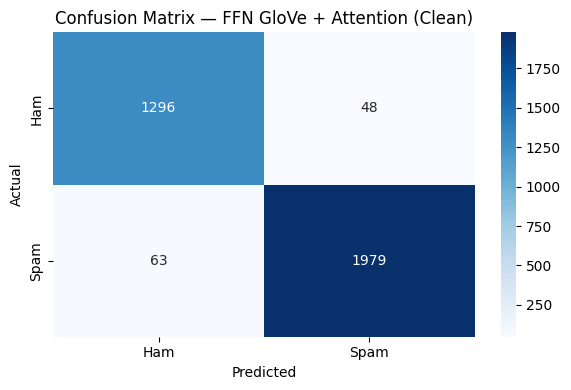

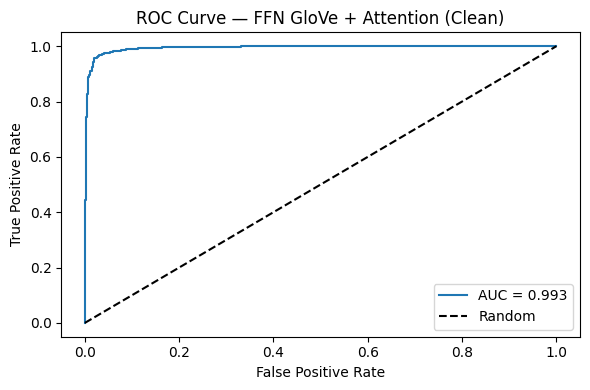

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Adversarial Test Set ===
              precision    recall  f1-score   support

         Ham       0.90      0.95      0.92      1344
        Spam       0.97      0.93      0.95      2042

    accuracy                           0.94      3386
   macro avg       0.93      0.94      0.94      3386
weighted avg       0.94      0.94      0.94      3386



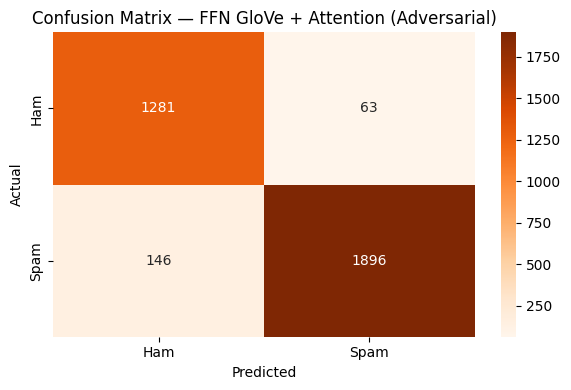

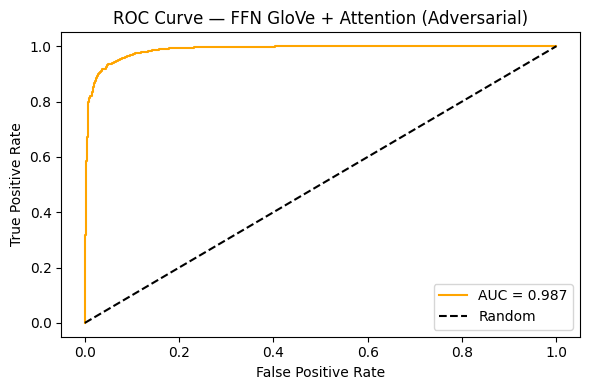

In [ ]:
# build & train FFNN using pretrained embeddings + attention
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Dense, Dropout, BatchNormalization,
    Softmax, Multiply, Lambda
)

def build_ffn_glove_attention(vocab_size, embed_dim, max_len, embedding_matrix, trainable=False):
    """
    FFNN using pretrained GloVe embeddings + attention.
    trainable=False  → frozen embeddings
    trainable=True   → fine-tune embeddings during training
    """
    inp = Input(shape=(max_len,))

    # Load pretrained GloVe embeddings
    x = Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=trainable
    )(inp)   # shape: (batch, max_len, embed_dim)

    # ── Attention mechanism ───────────────────────────────────────────────
    # Learn one score per token
    attn_scores = Dense(1, activation='tanh')(x)      # (batch, max_len, 1)

    # Convert scores into attention weights across the sequence
    attn_weights = Softmax(axis=1)(attn_scores)       # (batch, max_len, 1)

    # Weight each token embedding by its attention weight
    weighted_embeddings = Multiply()([x, attn_weights])  # (batch, max_len, embed_dim)

    # Sum across tokens → one attended message vector
    x = Lambda(lambda t: tf.reduce_sum(t, axis=1))(weighted_embeddings)  # (batch, embed_dim)

    # ── FFNN classifier ──────────────────────────────────────────────────
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)

    out = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inp, outputs=out)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


model_glove_attn = build_ffn_glove_attention(
    vocab_size, EMBED_DIM, MAX_LEN, embedding_matrix, trainable=True
)
model_glove_attn.summary()

# ── Train ────────────────────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping

history_attn = model_glove_attn.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=1
)

best_epoch_attn = np.argmin(history_attn.history['val_loss']) + 1
print(f"Best epoch: {best_epoch_attn}")
print(f"Best val_loss: {min(history_attn.history['val_loss']):.4f}")

# ── Evaluate on clean test set ───────────────────────────────────────────
y_pred_prob_attn = model_glove_attn.predict(X_test_seq).flatten()
y_pred_attn      = (y_pred_prob_attn >= 0.5).astype(int)

print("=== Clean Test Set ===")
print(classification_report(y_test, y_pred_attn, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_attn), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Blues')
plt.title('Confusion Matrix — FFN GloVe + Attention (Clean)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr_attn, tpr_attn, _ = roc_curve(y_test, y_pred_prob_attn)
roc_auc_attn = auc(fpr_attn, tpr_attn)
plt.figure(figsize=(6, 4))
plt.plot(fpr_attn, tpr_attn, label=f'AUC = {roc_auc_attn:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — FFN GloVe + Attention (Clean)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Evaluate on adversarial test set ─────────────────────────────────────
X_test_adv_seq = pad_sequences(
    tokenizer.texts_to_sequences(X_test_adv),
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

y_pred_adv_prob_attn = model_glove_attn.predict(X_test_adv_seq).flatten()
y_pred_adv_attn      = (y_pred_adv_prob_attn >= 0.5).astype(int)

print("=== Adversarial Test Set ===")
print(classification_report(y_test, y_pred_adv_attn, target_names=['Ham', 'Spam']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_adv_attn), annot=True, fmt='d',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'],
            cmap='Oranges')
plt.title('Confusion Matrix — FFN GloVe + Attention (Adversarial)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

fpr_adv_attn, tpr_adv_attn, _ = roc_curve(y_test, y_pred_adv_prob_attn)
roc_auc_adv_attn = auc(fpr_adv_attn, tpr_adv_attn)
plt.figure(figsize=(6, 4))
plt.plot(fpr_adv_attn, tpr_adv_attn, color='orange', label=f'AUC = {roc_auc_adv_attn:.3f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — FFN GloVe + Attention (Adversarial)')
plt.legend()
plt.tight_layout()
plt.show()

The model performed worse with frozen embeddings because GLoVe was trained on news articles and Wikipedia pages, while our dataset contains spam emails and messages. Unfreezing the embeddings improved performance because it allowed the model to adapt GLoVe to spam signals.

### Part 3: Bidirectional LSTM